# Resumo Macro

In [0]:
%sql
WITH resumo_num AS (
    SELECT 
        uf_sigla,
        total_internacoes,
        custo_total_rs,
        custo_medio_internacao,
        media_dias_permanencia,
        total_obitos,
        taxa_mortalidade_pct
    FROM mvp_saude.gold.gold_resumo_geral_rs
)
SELECT 
    uf_sigla AS UF,
    TRANSLATE(FORMAT_NUMBER(total_internacoes, 0), ',', '.') AS `Total de Internações`,
    CONCAT('R$ ', TRANSLATE(FORMAT_NUMBER(custo_total_rs, 2), ',.', '.,')) AS `Custo Total (R$)`,
    CONCAT('R$ ', TRANSLATE(FORMAT_NUMBER(custo_medio_internacao, 2), ',.', '.,')) AS `Custo Médio / Internação`,
    TRANSLATE(FORMAT_NUMBER(media_dias_permanencia, 1), ',.', '.,') AS `Média Dias Internado`,
    TRANSLATE(FORMAT_NUMBER(total_obitos, 0), ',', '.') AS `Total de Óbitos`,
    CONCAT(TRANSLATE(FORMAT_NUMBER(taxa_mortalidade_pct, 2), ',.', '.,'), '%') AS `Taxa de Mortalidade`
FROM resumo_num;

UF,Total de Internações,Custo Total (R$),Custo Médio / Internação,Média Dias Internado,Total de Óbitos,Taxa de Mortalidade
RS,63.922,"R$ 106.122.755,51","R$ 1.660,19","5,9",3.676,"5,75%"


### Top 10 Diagnósticos (CID) com Maior Volume

In [0]:
%sql
WITH diag_num AS (
    SELECT 
        cod_cid_principal,
        descricao_cid,
        total_internacoes,
        custo_total_cid,
        custo_medio_internacao,
        taxa_mortalidade_pct
    FROM mvp_saude.gold.gold_internacoes_por_diagnostico
)
SELECT 
    cod_cid_principal AS `Código CID-10`,
    descricao_cid AS `Descrição do Diagnóstico`,
    TRANSLATE(FORMAT_NUMBER(total_internacoes, 0), ',', '.') AS `Total Internações`,
    CONCAT('R$ ', TRANSLATE(FORMAT_NUMBER(custo_total_cid, 2), ',.', '.,')) AS `Custo Total (R$)`,
    CONCAT('R$ ', TRANSLATE(FORMAT_NUMBER(custo_medio_internacao, 2), ',.', '.,')) AS `Custo Médio`,
    CONCAT(TRANSLATE(FORMAT_NUMBER(taxa_mortalidade_pct, 2), ',.', '.,'), '%') AS `Taxa Mortalidade`
FROM diag_num
ORDER BY total_internacoes DESC
LIMIT 10;

Código CID-10,Descrição do Diagnóstico,Total Internações,Custo Total (R$),Custo Médio,Taxa Mortalidade
O800,Parto espontaneo cefalico,2.584,"R$ 1.561.610,53","R$ 604,34","0,00%"
J189,Pneumonia nao especificada,1.505,"R$ 1.883.725,99","R$ 1.251,65","13,09%"
J180,Broncopneumonia nao especificada,1.104,"R$ 1.258.393,24","R$ 1.139,85","11,59%"
B342,Infeccao por coronavirus de localizacao nao especificada,1.022,"R$ 4.647.961,55","R$ 4.547,91","21,33%"
I64,Acidente vascular cerebral,924,"R$ 1.362.773,52","R$ 1.474,86","14,18%"
O820,Parto por cesariana eletiva,826,"R$ 665.870,84","R$ 806,14","0,00%"
A499,Infeccao bacteriana nao especificada,812,"R$ 2.347.108,66","R$ 2.890,53","13,67%"
N390,Infeccao do trato urinario de localizacao nao especificada,760,"R$ 421.619,37","R$ 554,76","5,79%"
A419,Septicemia nao especificada,745,"R$ 2.757.013,75","R$ 3.700,69","44,56%"
I219,Infarto agudo do miocardio nao especificado,737,"R$ 3.735.505,53","R$ 5.068,53","7,73%"


Top 10 Municípios com Maior Número de Internações

In [0]:
%sql
WITH mun_num AS (
    SELECT 
        cod_municipio,
        nome_municipio,
        total_internacoes,
        custo_total_municipio,
        media_dias_permanencia,
        taxa_mortalidade_pct
    FROM mvp_saude.gold.gold_internacoes_por_municipio
)
SELECT 
    cod_municipio AS `Código IBGE`,
    nome_municipio AS `Município`,
    TRANSLATE(FORMAT_NUMBER(total_internacoes, 0), ',', '.') AS `Total Internações`,
    CONCAT('R$ ', TRANSLATE(FORMAT_NUMBER(custo_total_municipio, 2), ',.', '.,')) AS `Custo Total (R$)`,
    TRANSLATE(FORMAT_NUMBER(media_dias_permanencia, 1), ',.', '.,') AS `Média Dias Permanência`,
    CONCAT(TRANSLATE(FORMAT_NUMBER(taxa_mortalidade_pct, 2), ',.', '.,'), '%') AS `Taxa Mortalidade`
FROM mun_num
ORDER BY total_internacoes DESC
LIMIT 10;

Código IBGE,Município,Total Internações,Custo Total (R$),Média Dias Permanência,Taxa Mortalidade
430000,RS - Município Não Informado / Ignorado,27.614,"R$ 35.961.298,24","5,4","6,37%"
431490,Porto Alegre,14.404,"R$ 35.045.873,55","7,5","4,90%"
430460,Canoas,2.662,"R$ 5.213.285,55","5,1","3,19%"
430510,Caxias do Sul,2.339,"R$ 5.433.992,53","7,0","4,83%"
431440,Pelotas,2.035,"R$ 5.050.197,35","9,3","6,98%"
431340,Novo Hamburgo,1.185,"R$ 2.502.193,34","6,0","6,41%"
431680,Santa Cruz do Sul,1.108,"R$ 2.030.596,33","4,0","5,14%"
431870,São Leopoldo,910,"R$ 1.435.512,60","6,4","9,34%"
431140,Lajeado,855,"R$ 1.808.799,58","4,9","8,30%"
430920,Gravataí,647,"R$ 620.331,68","5,2","5,72%"


Diagnósticos com maior taxa de mortalidade

In [0]:

%sql
WITH mort_num AS (
    SELECT 
        cod_cid_principal,
        descricao_cid,
        total_internacoes,
        total_obitos,
        taxa_mortalidade_pct
    FROM mvp_saude.gold.gold_internacoes_por_diagnostico
    WHERE total_internacoes >= 20  -- Evita distorções de amostragem pequena
)
SELECT 
    cod_cid_principal AS `CID-10`,
    descricao_cid AS `Descrição do Diagnóstico`,
    TRANSLATE(FORMAT_NUMBER(total_internacoes, 0), ',', '.') AS `Total Internações`,
    TRANSLATE(FORMAT_NUMBER(total_obitos, 0), ',', '.') AS `Total Óbitos`,
    CONCAT(TRANSLATE(FORMAT_NUMBER(taxa_mortalidade_pct, 2), ',.', '.,'), '%') AS `Taxa Mortalidade`
FROM mort_num
ORDER BY taxa_mortalidade_pct DESC
LIMIT 10;

CID-10,Descrição do Diagnóstico,Total Internações,Total Óbitos,Taxa Mortalidade
I469,Parada cardiaca nao especificada,35,27,"77,14%"
A419,Septicemia nao especificada,745,332,"44,56%"
C229,Neoplasia maligna do figado,37,16,"43,24%"
A418,Outras septicemias especificadas,135,52,"38,52%"
J960,Insuficiencia respiratoria aguda,325,123,"37,85%"
A319,Infeccao micobacteriana nao especificada,48,18,"37,50%"
R571,Choque hipovolemico,24,9,"37,50%"
D487,Neoplasia de comportamento incerto ou desconhecido de outras localizacoes especificadas,27,10,"37,04%"
E440,Desnutricao proteico-calorica moderada,57,19,"33,33%"
J969,Insuficiencia respiratoria nao especificada,78,26,"33,33%"


# Gráficos e análises do Objetivo

In [0]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import pandas as pd
import seaborn as sns

In [0]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

# 1. Quais são as patologias (CIDs) e procedimentos que concentram o maior custo total por internação?

In [0]:
%sql
SELECT 
    cid.descricao_cid,
    COUNT(*) AS total_internacoes,
    FORMAT_NUMBER(SUM(s.VAL_TOT), 2) AS custo_total,
    FORMAT_NUMBER(AVG(s.VAL_TOT), 2) AS valor_medio_internacao
FROM mvp_saude.silver.sih_cleaned s
LEFT JOIN mvp_saude.silver.dim_cid10 cid 
    ON REPLACE(s.DIAG_PRINC, '.', '') = cid.cod_cid_principal
GROUP BY cid.descricao_cid
ORDER BY SUM(s.VAL_TOT) DESC
LIMIT 10;

descricao_cid,total_internacoes,custo_total,valor_medio_internacao
Infeccao por coronavirus de localizacao nao especificada,1022,"4,647,961.55","4,547.91"
Infarto agudo do miocardio nao especificado,737,"3,735,505.53","5,068.53"
Septicemia nao especificada,745,"2,757,013.75","3,700.69"
Angina instavel,522,"2,560,629.85","4,905.42"
Infeccao bacteriana nao especificada,812,"2,347,108.66","2,890.53"
Pneumonia nao especificada,1505,"1,883,725.99","1,251.65"
Parto espontaneo cefalico,2584,"1,561,610.53",604.34
Outros recem-nascidos de pre-termo,164,"1,545,801.30","9,425.62"
Insuficiencia cardiaca congestiva,632,"1,533,373.82","2,426.22"
Doenca renal em estadio final,159,"1,520,101.61","9,560.39"


/home/spark-f940e147-c6d6-42ad-acd8-83/.ipykernel/71/command-6789473014438314-3927568042:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=df_q1, x='custo_milhoes', y='descricao_cid', palette='Reds_r')


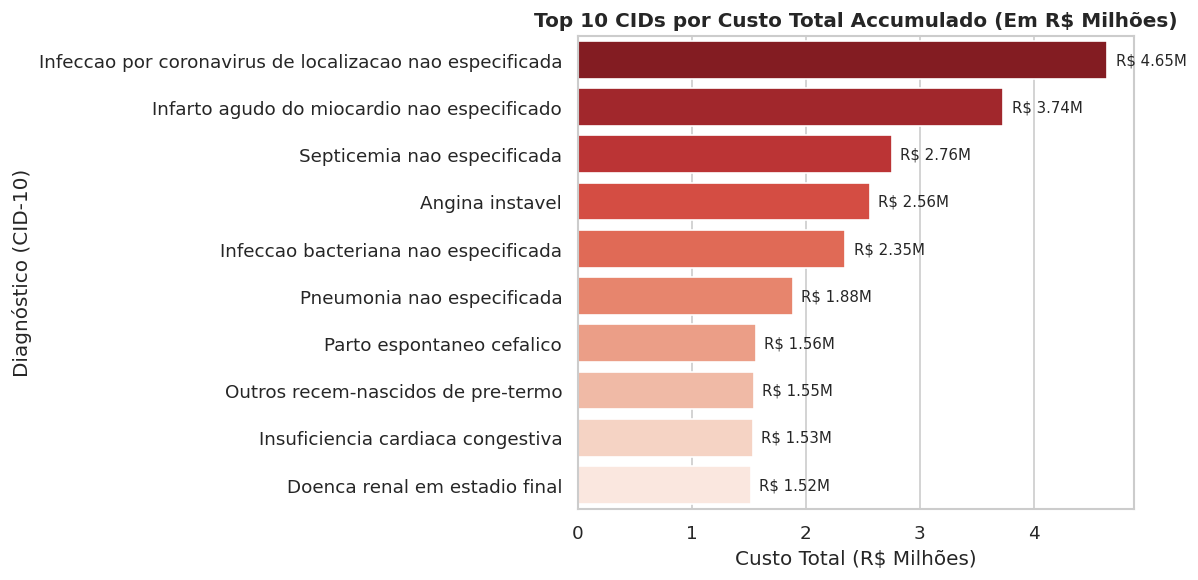

In [0]:
df_q1 = spark.sql("""
    WITH resumo_cid AS (
        SELECT 
            cid.descricao_cid,
            SUM(s.VAL_TOT) AS custo_total_num
        FROM mvp_saude.silver.sih_cleaned s
        LEFT JOIN mvp_saude.silver.dim_cid10 cid ON REPLACE(s.DIAG_PRINC, '.', '') = cid.cod_cid_principal
        GROUP BY cid.descricao_cid
    )
    SELECT descricao_cid, custo_total_num / 1e6 AS custo_milhoes
    FROM resumo_cid ORDER BY custo_total_num DESC LIMIT 10
""").toPandas()

plt.figure(figsize=(10, 5))
ax1 = sns.barplot(data=df_q1, x='custo_milhoes', y='descricao_cid', palette='Reds_r')
plt.title('Top 10 CIDs por Custo Total Accumulado (Em R$ Milhões)', fontsize=12, fontweight='bold')
plt.xlabel('Custo Total (R$ Milhões)')
plt.ylabel('Diagnóstico (CID-10)')
for p in ax1.patches:
    ax1.annotate(f'R$ {p.get_width():.2f}M', (p.get_width(), p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)
plt.tight_layout()
plt.show()

# 1.1 Quais são as patologias (CIDs) e procedimentos que concentram o maior valor médio por internação?

In [0]:
%sql
WITH resumo_cid AS (
    SELECT 
        cid.descricao_cid,
        COUNT(*) AS total_internacoes_num,
        SUM(s.VAL_TOT) AS custo_total_num,
        AVG(s.VAL_TOT) AS valor_medio_num
    FROM mvp_saude.silver.sih_cleaned s
    LEFT JOIN mvp_saude.silver.dim_cid10 cid 
        ON REPLACE(s.DIAG_PRINC, '.', '') = cid.cod_cid_principal
    GROUP BY cid.descricao_cid
    HAVING COUNT(*) >= 5
)
SELECT 
    descricao_cid,
    FORMAT_NUMBER(total_internacoes_num, 0) AS total_internacoes,
    TRANSLATE(FORMAT_NUMBER(custo_total_num, 2), ',.', '.,') AS custo_total,
    TRANSLATE(FORMAT_NUMBER(valor_medio_num, 2), ',.', '.,') AS valor_medio_internacao
FROM resumo_cid
ORDER BY valor_medio_num DESC
LIMIT 10;

descricao_cid,total_internacoes,custo_total,valor_medio_internacao
Insuficiencia respiratoria cronica,17,"566.447,00","33.320,41"
Flutter e fibrilacao ventricular,22,"547.896,36","24.904,38"
Aneurisma da aorta toracica,16,"339.289,74","21.205,61"
Tetralogia de Fallot,5,"98.660,27","19.732,05"
Comunicacao interventricular,7,"136.257,99","19.465,43"
Aneurisma de arteria iliaca,7,"131.918,83","18.845,55"
Aneurisma da aorta abdominal,20,"356.251,45","17.812,57"
Insuficiencia (da valva) mitral,10,"169.341,95","16.934,19"
Outras formas de cirrose hepatica e as nao especificadas,75,"1.190.555,62","15.874,07"
Insuficiencia hepatica,16,"248.532,95","15.533,31"


# 2. Qual é o tempo médio de permanência (dias em leito) por especialidade médica e faixa etária?

In [0]:
%sql
WITH resumo_permanencia AS (
    SELECT 
        e.descricao_especialidade AS especialidade_medica,
        CASE 
            WHEN INT(s.IDADE) < 18 THEN '0-17 anos'
            WHEN INT(s.IDADE) BETWEEN 18 AND 59 THEN '18-59 anos'
            WHEN INT(s.IDADE) >= 60 THEN '60+ anos'
            ELSE 'Não informada'
        END AS faixa_etaria,
        COUNT(*) AS qtd_internacoes_num,
        AVG(INT(s.DIAS_PERM)) AS tempo_medio_num
    FROM mvp_saude.silver.sih_cleaned s
    LEFT JOIN mvp_saude.silver.dim_especialidades e 
        ON LPAD(CAST(s.ESPEC AS STRING), 2, '0') = e.cod_especialidade
    GROUP BY 
        e.descricao_especialidade,
        CASE 
            WHEN INT(s.IDADE) < 18 THEN '0-17 anos'
            WHEN INT(s.IDADE) BETWEEN 18 AND 59 THEN '18-59 anos'
            WHEN INT(s.IDADE) >= 60 THEN '60+ anos'
            ELSE 'Não informada'
        END
)
SELECT 
    COALESCE(especialidade_medica, 'Outras / Não Informada') AS especialidade_medica,
    faixa_etaria,
    TRANSLATE(FORMAT_NUMBER(qtd_internacoes_num, 0), ',', '.') AS qtd_internacoes,
    TRANSLATE(FORMAT_NUMBER(tempo_medio_num, 1), ',.', '.,') AS tempo_medio_permanencia_dias
FROM resumo_permanencia
ORDER BY especialidade_medica, faixa_etaria;

especialidade_medica,faixa_etaria,qtd_internacoes,tempo_medio_permanencia_dias
Cirúrgica,0-17 anos,1.880,"3,4"
Cirúrgica,18-59 anos,12.419,"3,3"
Cirúrgica,60+ anos,8.006,"4,8"
Clínica Médica,0-17 anos,1.123,"5,8"
Clínica Médica,18-59 anos,9.654,"7,1"
Clínica Médica,60+ anos,14.093,"7,4"
Hanseníase,0-17 anos,5.437,"6,5"
Hanseníase,18-59 anos,98,"8,5"
Hanseníase,60+ anos,3,"1,0"
Obstétrica,0-17 anos,340,"2,7"


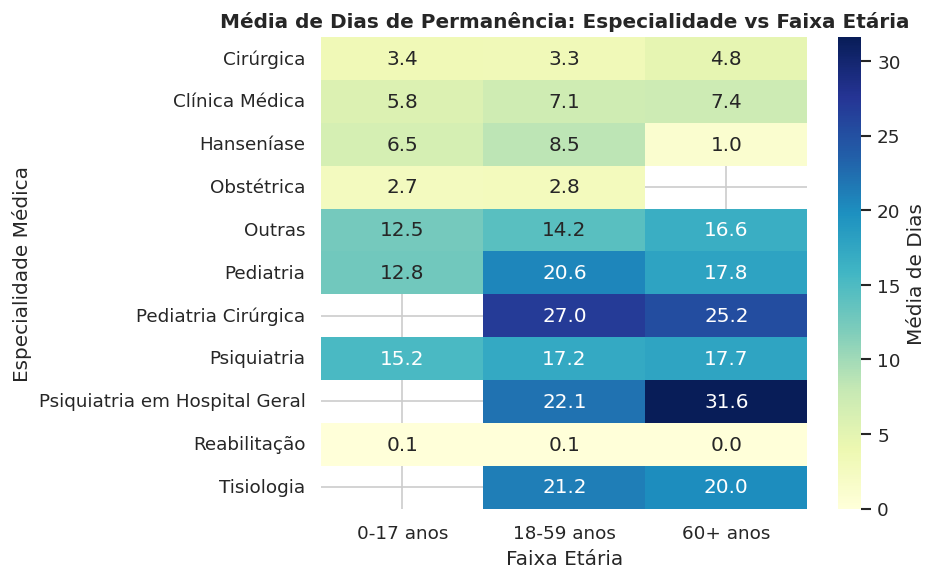

In [0]:
df_q2 = spark.sql("""
    SELECT 
        COALESCE(e.descricao_especialidade, 'Outras') AS especialidade,
        CASE 
            WHEN INT(s.IDADE) < 18 THEN '0-17 anos'
            WHEN INT(s.IDADE) BETWEEN 18 AND 59 THEN '18-59 anos'
            WHEN INT(s.IDADE) >= 60 THEN '60+ anos'
            ELSE 'Não informada'
        END AS faixa_etaria,
        ROUND(AVG(INT(s.DIAS_PERM)), 1) AS tempo_medio_dias
    FROM mvp_saude.silver.sih_cleaned s
    LEFT JOIN mvp_saude.silver.dim_especialidades e 
        ON LPAD(CAST(s.ESPEC AS STRING), 2, '0') = e.cod_especialidade
    GROUP BY 1, 2
""").toPandas()

pivot_q2 = df_q2.pivot(index='especialidade', columns='faixa_etaria', values='tempo_medio_dias')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_q2, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Média de Dias'})
plt.title('Média de Dias de Permanência: Especialidade vs Faixa Etária', fontsize=12, fontweight='bold')
plt.xlabel('Faixa Etária')
plt.ylabel('Especialidade Médica')
plt.tight_layout()
plt.show()

# 3. Qual é a taxa de mortalidade hospitalar cruzada por caráter de atendimento (Eletivo vs. Urgência/Emergência) e faixa etária?

In [0]:
%sql
WITH resumo_mortalidade AS (
    SELECT 
        CASE 
            WHEN s.CAR_INT IN ('01', '1') THEN 'Eletivo'
            WHEN s.CAR_INT IN ('02', '2') THEN 'Urgência / Emergência'
            ELSE CONCAT('Outros (', s.CAR_INT, ')')
        END AS carater_atendimento,
        CASE 
            WHEN INT(s.IDADE) < 18 THEN '0-17 anos'
            WHEN INT(s.IDADE) BETWEEN 18 AND 59 THEN '18-59 anos'
            WHEN INT(s.IDADE) >= 60 THEN '60+ anos'
            ELSE 'Não informada'
        END AS faixa_etaria,
        COUNT(*) AS total_internacoes_num,
        SUM(CASE WHEN INT(s.MORTE) = 1 THEN 1 ELSE 0 END) AS total_obitos_num,
        (SUM(CASE WHEN INT(s.MORTE) = 1 THEN 1 ELSE 0 END) * 100.0) / COUNT(*) AS taxa_mortalidade_num
    FROM mvp_saude.silver.sih_cleaned s
    GROUP BY 
        CASE 
            WHEN s.CAR_INT IN ('01', '1') THEN 'Eletivo'
            WHEN s.CAR_INT IN ('02', '2') THEN 'Urgência / Emergência'
            ELSE CONCAT('Outros (', s.CAR_INT, ')')
        END,
        CASE 
            WHEN INT(s.IDADE) < 18 THEN '0-17 anos'
            WHEN INT(s.IDADE) BETWEEN 18 AND 59 THEN '18-59 anos'
            WHEN INT(s.IDADE) >= 60 THEN '60+ anos'
            ELSE 'Não informada'
        END
)
SELECT 
    carater_atendimento,
    faixa_etaria,
    TRANSLATE(FORMAT_NUMBER(total_internacoes_num, 0), ',', '.') AS total_internacoes,
    TRANSLATE(FORMAT_NUMBER(total_obitos_num, 0), ',', '.') AS total_obitos,
    TRANSLATE(FORMAT_NUMBER(taxa_mortalidade_num, 2), ',.', '.,') AS taxa_mortalidade_pct
FROM resumo_mortalidade
ORDER BY carater_atendimento, faixa_etaria;

carater_atendimento,faixa_etaria,total_internacoes,total_obitos,taxa_mortalidade_pct
Eletivo,0-17 anos,1.705,2,"0,12"
Eletivo,18-59 anos,8.428,43,"0,51"
Eletivo,60+ anos,5.781,221,"3,82"
Outros (05),0-17 anos,4,0,"0,00"
Outros (05),18-59 anos,14,0,"0,00"
Outros (05),60+ anos,3,0,"0,00"
Outros (06),0-17 anos,2,0,"0,00"
Outros (06),18-59 anos,37,1,"2,70"
Outros (06),60+ anos,18,0,"0,00"
Urgência / Emergência,0-17 anos,7.366,94,"1,28"


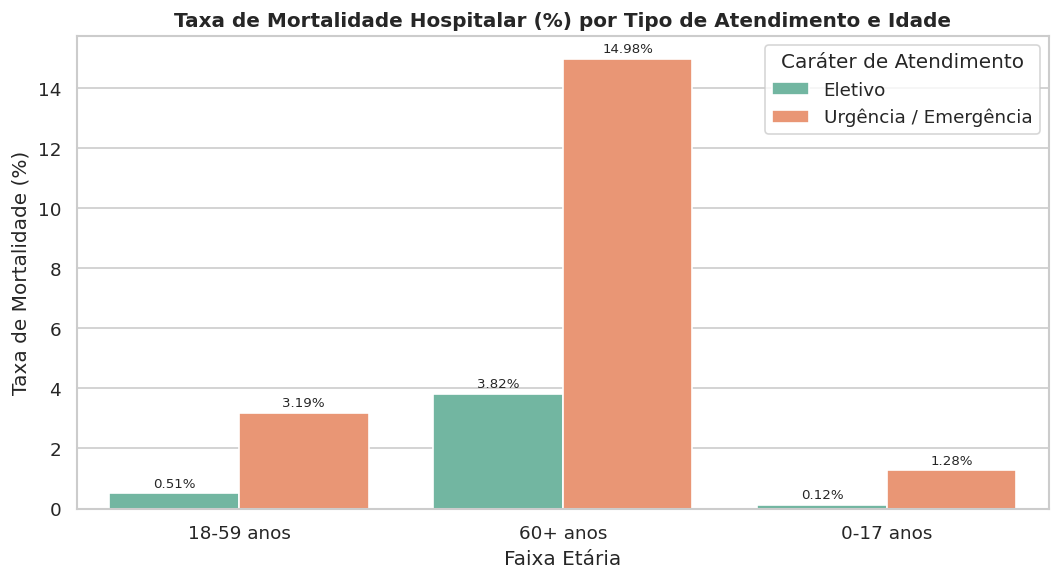

In [0]:
df_q3 = spark.sql("""
    SELECT 
        CASE 
            WHEN s.CAR_INT IN ('01', '1') THEN 'Eletivo'
            WHEN s.CAR_INT IN ('02', '2') THEN 'Urgência / Emergência'
            ELSE 'Outros'
        END AS carater_atendimento,
        CASE 
            WHEN INT(s.IDADE) < 18 THEN '0-17 anos'
            WHEN INT(s.IDADE) BETWEEN 18 AND 59 THEN '18-59 anos'
            WHEN INT(s.IDADE) >= 60 THEN '60+ anos'
            ELSE 'Não informada'
        END AS faixa_etaria,
        ROUND((SUM(CASE WHEN INT(s.MORTE) = 1 THEN 1 ELSE 0 END) * 100.0) / COUNT(*), 2) AS taxa_mortalidade_pct
    FROM mvp_saude.silver.sih_cleaned s
    WHERE s.CAR_INT IN ('01', '1', '02', '2')
    GROUP BY 1, 2
""").toPandas()

plt.figure(figsize=(9, 5))
ax3 = sns.barplot(data=df_q3, x='faixa_etaria', y='taxa_mortalidade_pct', hue='carater_atendimento', palette='Set2')
plt.title('Taxa de Mortalidade Hospitalar (%) por Tipo de Atendimento e Idade', fontsize=12, fontweight='bold')
plt.xlabel('Faixa Etária')
plt.ylabel('Taxa de Mortalidade (%)')
plt.legend(title='Caráter de Atendimento')
for p in ax3.patches:
    if p.get_height() > 0:
        ax3.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=8, xytext=(0, 2), textcoords='offset points')
plt.tight_layout()
plt.show()

# 4. Existe variação significativa no custo médio por internação entre os diferentes municípios do RS?

In [0]:
%sql
WITH resumo_municipios AS (
    SELECT 
        m.nome_municipio,
        COUNT(*) AS total_internacoes_num,
        SUM(s.VAL_TOT) AS custo_total_num,
        AVG(s.VAL_TOT) AS valor_medio_num
    FROM mvp_saude.silver.sih_cleaned s
    LEFT JOIN mvp_saude.silver.dim_municipios m 
        ON CAST(s.MUNIC_MOV AS STRING) = CAST(m.cod_municipio AS STRING)
    GROUP BY m.nome_municipio
)
SELECT 
    nome_municipio,
    TRANSLATE(FORMAT_NUMBER(total_internacoes_num, 0), ',', '.') AS total_internacoes,
    TRANSLATE(FORMAT_NUMBER(custo_total_num, 2), ',.', '.,') AS custo_total,
    TRANSLATE(FORMAT_NUMBER(valor_medio_num, 2), ',.', '.,') AS valor_medio_internacao
FROM resumo_municipios
ORDER BY valor_medio_num DESC
LIMIT 20;

nome_municipio,total_internacoes,custo_total,valor_medio_internacao
Ijuí,1.096,"2.950.348,52","2.691,92"
Passo Fundo,2.808,"7.495.981,70","2.669,51"
Pelotas,2.035,"5.050.197,35","2.481,67"
Porto Alegre,14.404,"35.045.873,55","2.433,07"
Osório,223,"526.376,14","2.360,43"
Guaíba,62,"145.075,65","2.339,93"
Caxias do Sul,2.339,"5.433.992,53","2.323,21"
Lajeado,855,"1.808.799,58","2.115,56"
Novo Hamburgo,1.185,"2.502.193,34","2.111,56"
Canguçu,184,"379.873,16","2.064,53"


/home/spark-f940e147-c6d6-42ad-acd8-83/.ipykernel/71/command-6789473014438317-4132730729:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax4 = sns.barplot(data=df_q4, x='valor_medio_num', y='nome_municipio', palette='Blues_r')


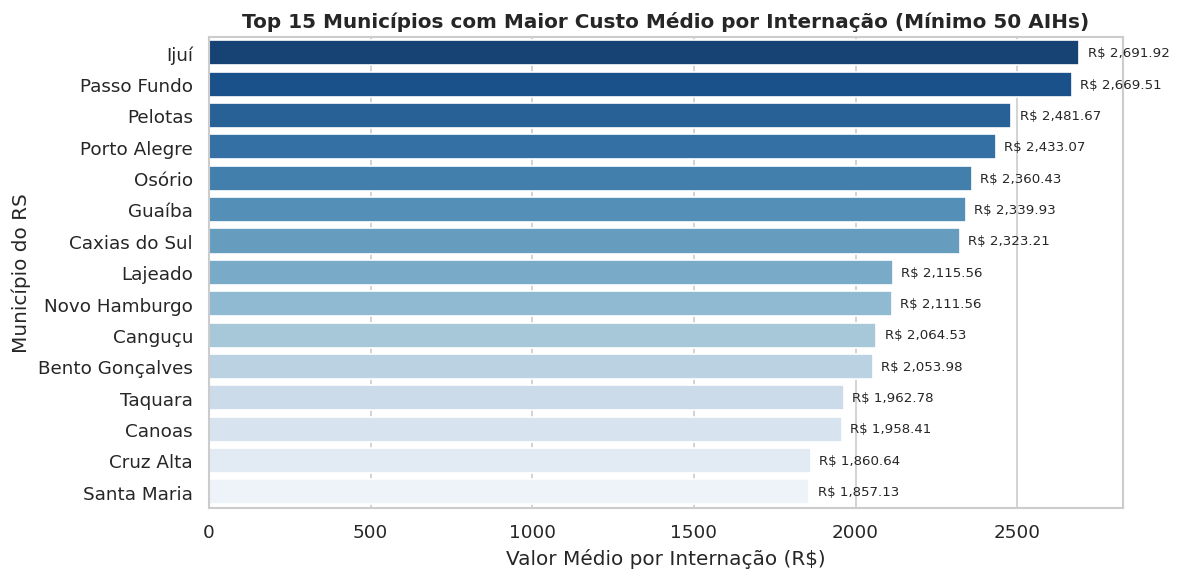

In [0]:
df_q4 = spark.sql("""
    SELECT 
        m.nome_municipio,
        AVG(s.VAL_TOT) AS valor_medio_num
    FROM mvp_saude.silver.sih_cleaned s
    LEFT JOIN mvp_saude.silver.dim_municipios m 
        ON CAST(s.MUNIC_MOV AS STRING) = CAST(m.cod_municipio AS STRING)
    GROUP BY m.nome_municipio
    HAVING COUNT(*) >= 50
    ORDER BY valor_medio_num DESC
    LIMIT 15
""").toPandas()

plt.figure(figsize=(10, 5))
ax4 = sns.barplot(data=df_q4, x='valor_medio_num', y='nome_municipio', palette='Blues_r')
plt.title('Top 15 Municípios com Maior Custo Médio por Internação (Mínimo 50 AIHs)', fontsize=12, fontweight='bold')
plt.xlabel('Valor Médio por Internação (R$)')
plt.ylabel('Município do RS')
for p in ax4.patches:
    ax4.annotate(f'R$ {p.get_width():,.2f}', (p.get_width(), p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=8)
plt.tight_layout()
plt.show()

Maior custo médio por internação por Região do RS

In [0]:
%sql

WITH analise_regional AS (
    SELECT 
        regiao_saude,
        total_internacoes_regiao,
        custo_total_regiao,
        custo_medio_internacao_regiao,
        total_obitos_regiao,
        taxa_mortalidade_regiao_pct
    FROM mvp_saude.gold.gold_custo_medio_por_regiao
)
SELECT 
    regiao_saude AS `Região de Saúde`,
    TRANSLATE(FORMAT_NUMBER(total_internacoes_regiao, 0), ',', '.') AS `Total de Internações`,
    CONCAT('R$ ', TRANSLATE(FORMAT_NUMBER(custo_total_regiao, 2), ',.', '.,')) AS `Custo Total (R$)`,
    CONCAT('R$ ', TRANSLATE(FORMAT_NUMBER(custo_medio_internacao_regiao, 2), ',.', '.,')) AS `Custo Médio / Internação`,
    TRANSLATE(FORMAT_NUMBER(total_obitos_regiao, 0), ',', '.') AS `Total de Óbitos`,
    CONCAT(TRANSLATE(FORMAT_NUMBER(taxa_mortalidade_regiao_pct, 2), ',.', '.,'), '%') AS `Taxa de Mortalidade (%)`
FROM analise_regional
ORDER BY custo_medio_internacao_regiao DESC;

Região de Saúde,Total de Internações,Custo Total (R$),Custo Médio / Internação,Total de Óbitos,Taxa de Mortalidade (%)
Sul,2.035,"R$ 5.050.197,35","R$ 2.481,67",142,"6,98%"
Metropolitana e Litoral,20.268,"R$ 44.996.911,45","R$ 2.220,10",984,"4,85%"
Nordeste / Serra,4.668,"R$ 8.321.015,20","R$ 1.782,57",211,"4,52%"
Vales (Taquari e Rio Pardo),3.890,"R$ 6.144.155,17","R$ 1.579,47",233,"5,99%"
Noroeste / Missões,1.129,"R$ 1.516.055,04","R$ 1.342,83",56,"4,96%"
Demais Municípios do Interior,31.372,"R$ 39.499.014,42","R$ 1.259,05",2.019,"6,44%"
Norte,440,"R$ 535.714,47","R$ 1.217,53",24,"5,45%"
Fronteira Oeste,120,"R$ 59.692,41","R$ 497,44",7,"5,83%"


In [0]:
df_spark = spark.table("mvp_saude.gold.gold_custo_medio_por_regiao")
df_pandas = df_spark.toPandas()

In [0]:
fig = px.bar(
    df_pandas,
    x="regiao_saude",
    y="custo_medio_internacao_regiao",
    title="Custo Médio por Internação (R$) por Região de Saúde - RS",
    labels={
        "regiao_saude": "Região de Saúde",
        "custo_medio_internacao_regiao": "Custo Médio (R$)",
    },
    text_auto=".2f",  # Mostra os valores nas barras
    color="custo_medio_internacao_regiao",
    color_continuous_scale="Blues",
)

In [0]:
fig.update_layout(
    xaxis_tickangle=-45,
    xaxis_title="Região de Saúde",
    yaxis_title="Custo Médio por Internação (R$)",
    template="plotly_white",
)